<a href="https://colab.research.google.com/github/vedantiraut15/Artificial_Intelligence_Lab_SE-A-50/blob/master/Practical_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Load Dataset

In [5]:
# Load dataset
df = pd.read_csv("retail_sales_dataset.csv")

# Preview data
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


# Data Preparation

In [7]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create Month-Year column
df['Month_Year'] = df['Date'].dt.to_period('M')

# KPI Calculations : Total sales and units sold

In [9]:
total_sales = df['Total Amount'].sum()
total_units = df['Quantity'].sum()

print("Total Sales:", total_sales)
print("Total Units Sold:", total_units)

Total Sales: 456000
Total Units Sold: 2514


# Top 5 Products by Sales  

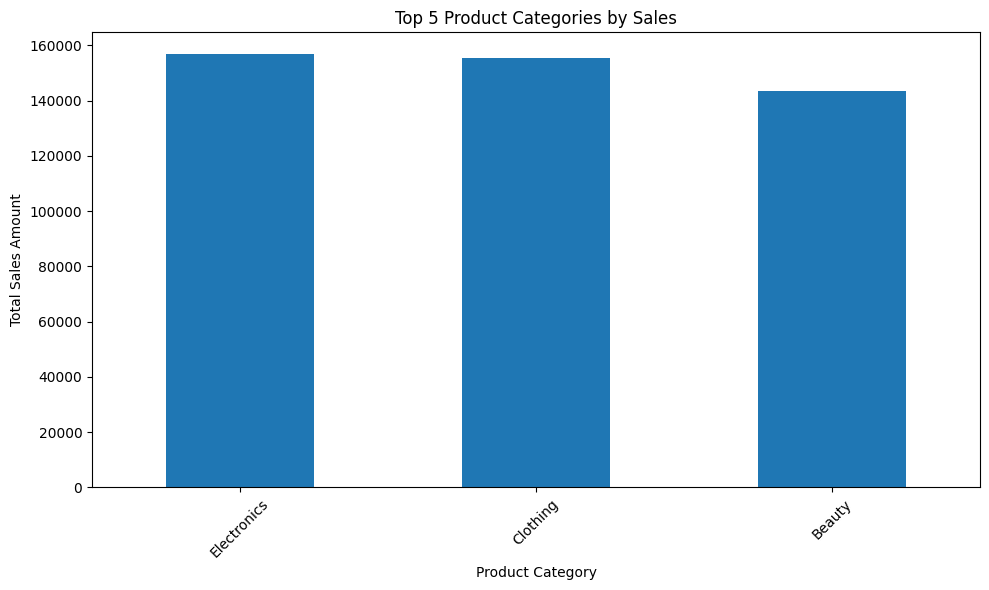

In [11]:
top_products = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 6))
top_products.plot(kind='bar')
plt.title("Top 5 Product Categories by Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Monthly Sales Trend (Line Chart)

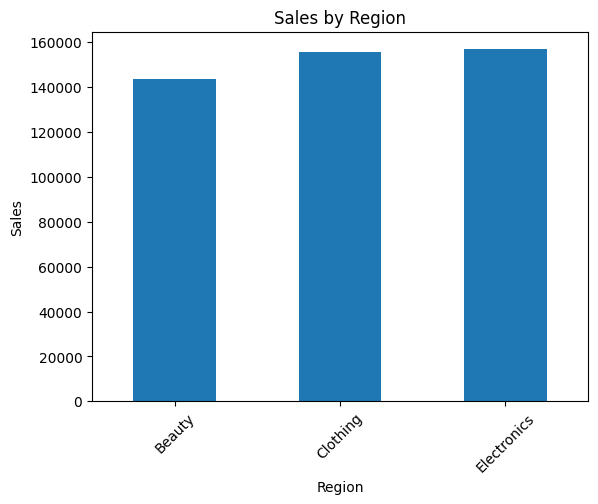

In [16]:
sales_region = df.groupby('Product Category')['Total Amount'].sum()

plt.figure()
sales_region.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# Monthly Sales Trend (Line Chart)

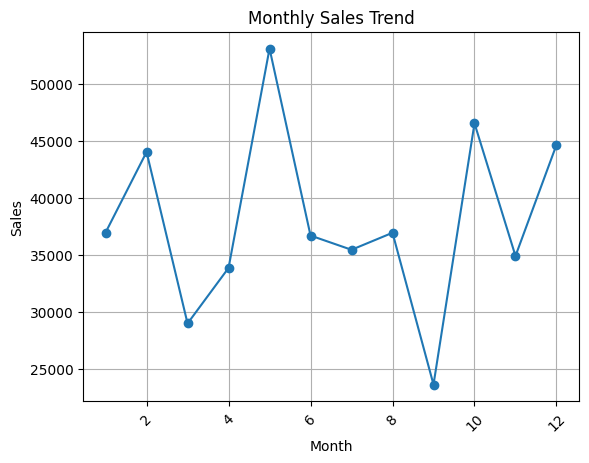

In [18]:
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()